# Slicing NDDatasets

This tutorial shows how to handle NDDatasets using python slicing. As prerequisite, the user is
expected to have read the [Import Tutorials](../importexport/import.rst).

In [1]:
import numpy as np

import spectrochempy as scp

## What is the slicing ?

The slicing of a list or an array means taking elements from a given index
(or set of indexes) to another index (or set of indexes).
Slicing is specified using the colon operator `:` with a `from` and `to` index
before and after the first column, and a `step` after the second column.
Hence, a slice of the object `X` will be set as:

`X[from:to:step]`

and will extend from the ‘from’ index, ends one item before the ‘to’ index
and with an increment of `step`between each index. When not given the default
values are respectively 0 (i.e. starts at the 1st index),
length in the dimension (stops at the last index), and 1.

Let's first illustrate the concept on a 1D example:

In [2]:
X = np.arange(10)  # generates a 1D array of 10 elements from 0 to 9
print(X)
print(X[2:5])  # selects all elements from 2 to 4
print(X[::2])  # selects one out of two elements
print(X[:-3])  # a negative index will be counted from the end of the array
print(
    X[::-2]
)  # a negative step will slice backward, starting from 'to', ending at 'from'

[0 1 2 3 4 5 6 7 8 9]
[2 3 4]
[0 2 4 6 8]
[0 1 2 3 4 5 6]
[9 7 5 3 1]


The same applies to multidimensional arrays by indicating slices separated by commas:

In [3]:
X = np.random.rand(10, 10)  # generates a 10x10 array filled with random values
print(X.shape)
print(X[2:5, :].shape)  # slices along the 1st dimension, X[2:5,] is equivalent
print(
    X[2:5, ::2].shape
)  # same slice along 1st dimension and takes one 1 column out of two along the second

(10, 10)
(3, 10)
(3, 5)


## Slicing of NDDatasets

Let's import a group of IR spectra, look at its content and plot it:

In [4]:
X = scp.read_omnic("irdata/CO@Mo_Al2O3.SPG", description="CO adsorption, diff spectra")
X.y = (X.y - X[0].y).to("minute")
X

NDDataset: [float64] a.u. (shape: (y:19, x:3112))

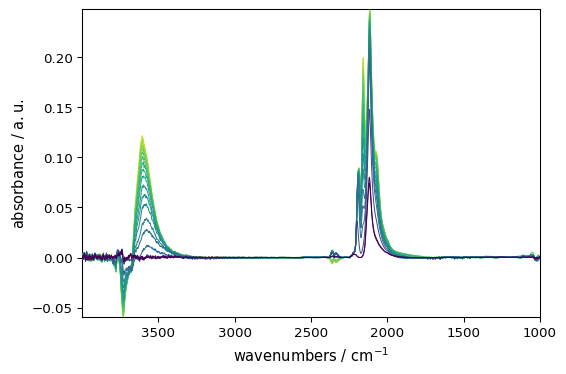

In [5]:
subplot = X.plot()  # assignment avoids the display of the object address (<matplotlib.axes._subplots.AxesSubplot ...)

### Slicing with indexes

The classical slicing, using integers, can be used. For instance, along the 1st dimension:

In [6]:
print(X[:4])  # selects the first four spectra
print(X[-3:])  # selects the last three spectra
print(X[::2])  # selects one spectrum out of 2

NDDataset: [float64] a.u. (shape: (y:4, x:3112))
NDDataset: [float64] a.u. (shape: (y:3, x:3112))
NDDataset: [float64] a.u. (shape: (y:10, x:3112))


The same can be made along the second dimension, simultaneously or not with the first one. For instance

In [7]:
print(
    X[:, ::2]
)  # all spectra, one wavenumber out of 2   (note the bug: X[,::2] generates an error)
print(
    X[0:3, 200:1000:2]
)  # 3 first spectra, one wavenumbers out of 2, from index 200 to 1000

NDDataset: [float64] a.u. (shape: (y:19, x:1556))
NDDataset: [float64] a.u. (shape: (y:3, x:400))


Would you easily guess which wavenumber range have been actually selected ?...
probably not because the relationship between the index and the wavenumber
is not straightforward as it depends on the value of the first wavenumber,
the wavenumber spacing, and whether the wavenumbers are arranged in ascending
or descending order...
Here is the answer:

In [8]:
X[
    :, 200:1000:2
].x  # as the Coord can be sliced, the same is obtained with: X.x[200:1000:2]

Coord: [float64] cm⁻¹ (size: 400)

### Slicing with coordinates

Now the spectroscopist is generally interested in a particular region of the
spectrum, for instance, 2300-1900 cm$^{-1}$. Can you easily guess the indexes
that one should use to spectrum this region ? probably not without a calculator...

Fortunately, a simple mechanism has been implemented in spectrochempy
for this purpose: the use of floats instead of integers will slice the
NDDataset at the corresponding coordinates. For instance to select the 2300-1900 cm$^{-1}$ region:

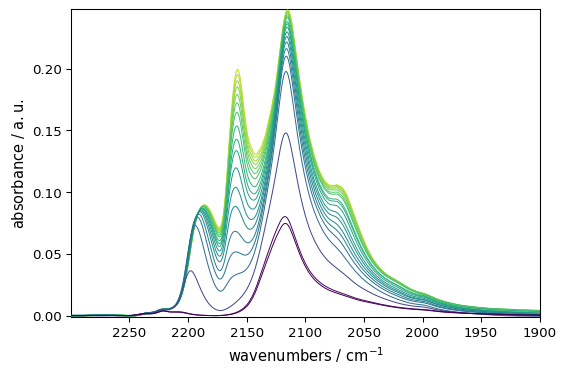

In [9]:
subplot = X[:, 2300.0:1900.0:].plot()

The same mechanism can be used along the first dimension (`y` ).
For instance, to select and plot the same region and the spectra recorded between 80 and 180 minutes:

INFO | This coordinate (180.0) is outside the axis limits (0.0-137.033).
The closest limit index is returned


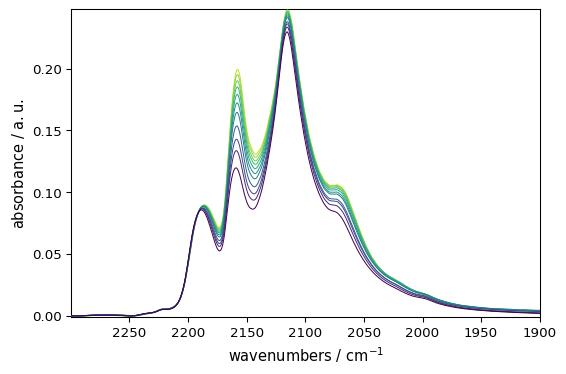

In [10]:
subplot = X[
    80.0:180.0, 2300.0:1900.0
].plot()  # Note that a decimal point is enough to get a float
# a warning is raised if one or several values are beyond the limits

Similarly, the spectrum recorded at the time the closest to 60 minutes can be selected using a float:

In [11]:
X[60.0].y  # X[60.] slices the spectrum,  .y returns the corresponding `y` axis.

Coord: [float64] min (size: 1)

--- End of Tutorial ---
   (todo: add advanced slicing by array of indexes, array of bool,  ...)